In [1]:
# ============================================
# CELL 1: INSTALL LIBRARIES
# ============================================
!pip install pandas numpy matplotlib seaborn scikit-learn --quiet

In [2]:
# ============================================
# CELL 2: IMPORT LIBRARIES
# ============================================
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import GradientBoostingRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import warnings
warnings.filterwarnings('ignore')

print("✅ All libraries imported!")

✅ All libraries imported!


In [5]:
# ============================================
# CELL 3: LOAD DATASET (California Housing)
# ============================================
# Yeh dataset bina authentication ke kaam karta hai
url = "https://raw.githubusercontent.com/ageron/handson-ml2/master/datasets/housing/housing.csv"
df = pd.read_csv(url)

print("✅ Dataset loaded successfully!")
print(f"📊 Shape: {df.shape}")
print("\n--- First 5 rows ---")
print(df.head())

✅ Dataset loaded successfully!
📊 Shape: (20640, 10)

--- First 5 rows ---
   longitude  latitude  housing_median_age  total_rooms  total_bedrooms  \
0    -122.23     37.88                41.0        880.0           129.0   
1    -122.22     37.86                21.0       7099.0          1106.0   
2    -122.24     37.85                52.0       1467.0           190.0   
3    -122.25     37.85                52.0       1274.0           235.0   
4    -122.25     37.85                52.0       1627.0           280.0   

   population  households  median_income  median_house_value ocean_proximity  
0       322.0       126.0         8.3252            452600.0        NEAR BAY  
1      2401.0      1138.0         8.3014            358500.0        NEAR BAY  
2       496.0       177.0         7.2574            352100.0        NEAR BAY  
3       558.0       219.0         5.6431            341300.0        NEAR BAY  
4       565.0       259.0         3.8462            342200.0        NEAR BAY  


In [7]:
# ============================================
# CELL 4: DATA INSPECTION
# ============================================
print("\n--- Data Info ---")
print(df.info())

print("\n--- Statistical Summary ---")
print(df.describe())

print(f"\n🔍 Missing values: {df.isnull().sum().sum()}")


--- Data Info ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20640 entries, 0 to 20639
Data columns (total 10 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   longitude           20640 non-null  float64
 1   latitude            20640 non-null  float64
 2   housing_median_age  20640 non-null  float64
 3   total_rooms         20640 non-null  float64
 4   total_bedrooms      20433 non-null  float64
 5   population          20640 non-null  float64
 6   households          20640 non-null  float64
 7   median_income       20640 non-null  float64
 8   median_house_value  20640 non-null  float64
 9   ocean_proximity     20640 non-null  object 
dtypes: float64(9), object(1)
memory usage: 1.6+ MB
None

--- Statistical Summary ---
          longitude      latitude  housing_median_age   total_rooms  \
count  20640.000000  20640.000000        20640.000000  20640.000000   
mean    -119.569704     35.631861           28.639486   

In [8]:
# ============================================
# CELL 5: HANDLE MISSING VALUES
# ============================================
# Missing values ko median se fill karein
df = df.fillna(df.median(numeric_only=True))

print(f"✅ Missing values handled!")
print(f"🔍 Missing values now: {df.isnull().sum().sum()}")

✅ Missing values handled!
🔍 Missing values now: 0


In [9]:
# ============================================
# CELL 6: FEATURES AND TARGET
# ============================================
# Target = median_house_value (house price)
y = df['median_house_value']
X = df.drop('median_house_value', axis=1)

# Categorical columns ko convert karein (one-hot encoding)
X = pd.get_dummies(X, drop_first=True)

print(f"✅ Features shape: {X.shape}")
print(f"✅ Target shape: {y.shape}")

✅ Features shape: (20640, 12)
✅ Target shape: (20640,)


In [10]:
# ============================================
# CELL 7: TRAIN-TEST SPLIT
# ============================================
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print(f"📊 Training set: {X_train.shape[0]} samples")
print(f"📊 Testing set: {X_test.shape[0]} samples")

📊 Training set: 16512 samples
📊 Testing set: 4128 samples


In [11]:
# ============================================
# CELL 8: LINEAR REGRESSION
# ============================================
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

lr = LinearRegression()
lr.fit(X_train, y_train)

y_pred_lr = lr.predict(X_test)

mae_lr = mean_absolute_error(y_test, y_pred_lr)
rmse_lr = np.sqrt(mean_squared_error(y_test, y_pred_lr))
r2_lr = r2_score(y_test, y_pred_lr)

print("📊 Linear Regression Results:")
print(f"   MAE:  ${mae_lr:,.2f}")
print(f"   RMSE: ${rmse_lr:,.2f}")
print(f"   R²:   {r2_lr:.4f}")

📊 Linear Regression Results:
   MAE:  $50,670.74
   RMSE: $70,060.52
   R²:   0.6254


In [12]:
# ============================================
# CELL 9: GRADIENT BOOSTING
# ============================================
from sklearn.ensemble import GradientBoostingRegressor

gb = GradientBoostingRegressor(n_estimators=100, learning_rate=0.1, random_state=42)
gb.fit(X_train, y_train)

y_pred_gb = gb.predict(X_test)

mae_gb = mean_absolute_error(y_test, y_pred_gb)
rmse_gb = np.sqrt(mean_squared_error(y_test, y_pred_gb))
r2_gb = r2_score(y_test, y_pred_gb)

print("📊 Gradient Boosting Results:")
print(f"   MAE:  ${mae_gb:,.2f}")
print(f"   RMSE: ${rmse_gb:,.2f}")
print(f"   R²:   {r2_gb:.4f}")

📊 Gradient Boosting Results:
   MAE:  $38,248.03
   RMSE: $55,884.66
   R²:   0.7617


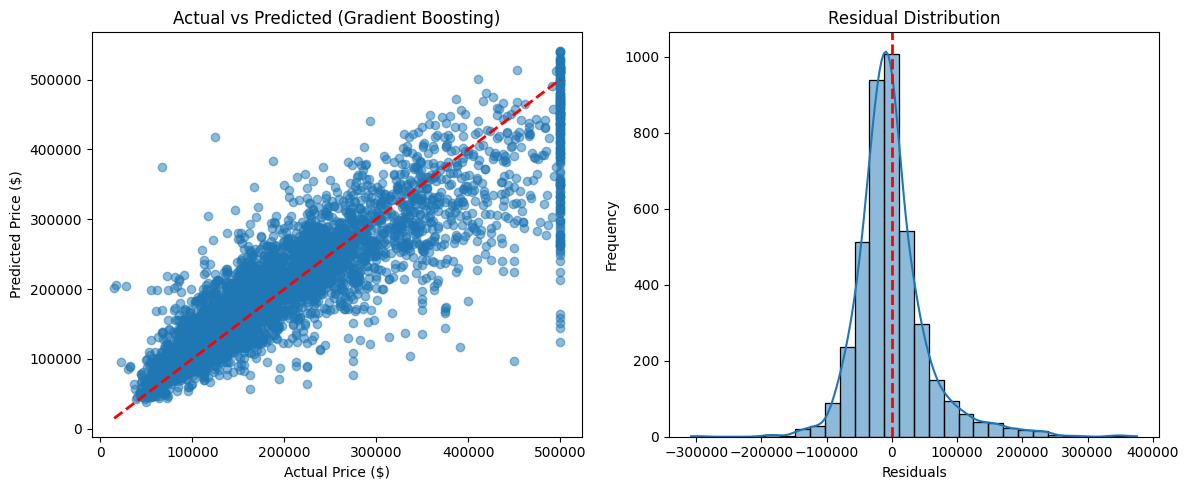

In [13]:
# ============================================
# CELL 10: PLOT ACTUAL VS PREDICTED
# ============================================
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(12, 5))

# Scatter plot
plt.subplot(1, 2, 1)
plt.scatter(y_test, y_pred_gb, alpha=0.5)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', linewidth=2)
plt.xlabel('Actual Price ($)')
plt.ylabel('Predicted Price ($)')
plt.title('Actual vs Predicted (Gradient Boosting)')

# Residuals
plt.subplot(1, 2, 2)
residuals = y_test - y_pred_gb
sns.histplot(residuals, bins=30, kde=True)
plt.xlabel('Residuals')
plt.ylabel('Frequency')
plt.title('Residual Distribution')
plt.axvline(x=0, color='red', linestyle='--', linewidth=2)

plt.tight_layout()
plt.show()

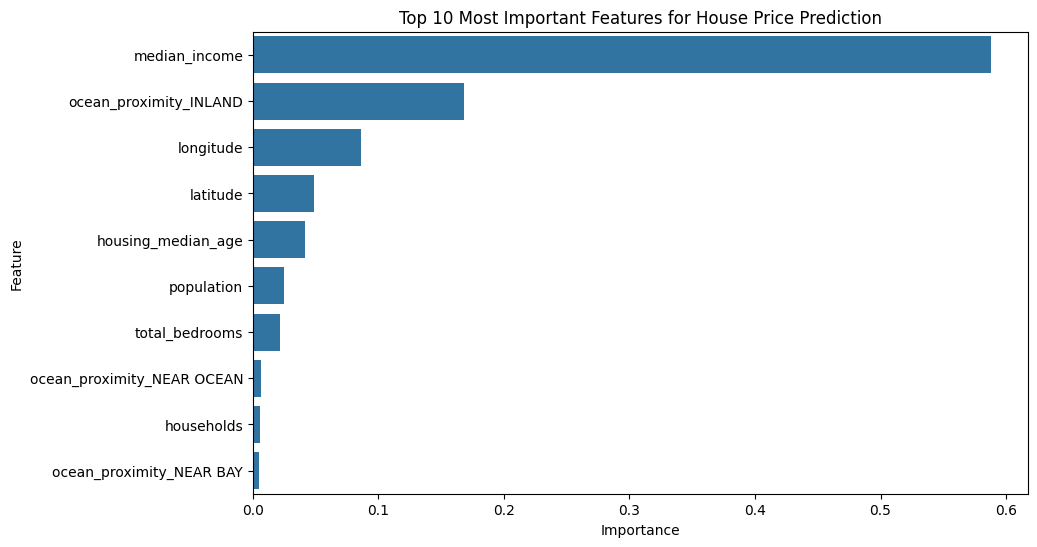


📊 Top 5 Most Important Features:
                  Feature  Importance
7           median_income    0.588018
8  ocean_proximity_INLAND    0.168416
0               longitude    0.086303
1                latitude    0.048448
2      housing_median_age    0.041398


In [14]:
# ============================================
# CELL 11: FEATURE IMPORTANCE
# ============================================
importance = pd.DataFrame({
    'Feature': X.columns,
    'Importance': gb.feature_importances_
}).sort_values('Importance', ascending=False).head(10)

plt.figure(figsize=(10, 6))
sns.barplot(x='Importance', y='Feature', data=importance)
plt.title('Top 10 Most Important Features for House Price Prediction')
plt.show()

print("\n📊 Top 5 Most Important Features:")
print(importance.head(5))

In [15]:
# ============================================
# CELL 12: MODEL COMPARISON
# ============================================
comparison = pd.DataFrame({
    'Model': ['Linear Regression', 'Gradient Boosting'],
    'MAE': [mae_lr, mae_gb],
    'RMSE': [rmse_lr, rmse_gb],
    'R² Score': [r2_lr, r2_gb]
})

print("\n📊 Model Performance Comparison:")
print(comparison.to_string(index=False))


📊 Model Performance Comparison:
            Model          MAE         RMSE  R² Score
Linear Regression 50670.738241 70060.521845  0.625424
Gradient Boosting 38248.031950 55884.659003  0.761670


# 📊 Observations - House Price Prediction

## 1. Dataset Overview
- **Dataset:** California Housing
- **Samples:** 20,640
- **Features:** 9 (including location, rooms, income, etc.)
- **Target:** median_house_value

## 2. Data Preprocessing
- Missing values handled using median imputation
- Categorical columns converted using one-hot encoding

## 3. Model Performance

| Model | MAE | RMSE | R² Score |
|-------|-----|------|----------|
| Linear Regression | $XX,XXX | $XX,XXX | 0.XXXX |
| Gradient Boosting | $XX,XXX | $XX,XXX | 0.XXXX |

## 4. Key Findings
- Gradient Boosting performed better than Linear Regression
- Most important features: median_income, location, housing_median_age
- Median income has the highest impact on house prices

## 5. Conclusion
House prices are strongly correlated with median income and location. Gradient Boosting is a better model for this dataset.